In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import hashlib
import matplotlib.ticker as ticker

def nd(arr):
    return np.asarray(arr).reshape(-1)

def yex(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    # now plot both limits against eachother
    ax.plot(lims, lims, c="k", alpha=0.75, zorder=0)
    ax.set(**{"aspect": "equal", "xlim": lims, "ylim": lims})
    return ax

def short_hash(s: str) -> str:
    """Generate a 7-character hash from a given string."""
    return hashlib.sha256(s.encode()).hexdigest()[:7]

fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'


In [2]:
from taln.taln_aln import (
    norm_text,
    tokenize,
    align_ng,
    align_lcs,
    align_difflib,
    reconstruct_target_by_idx,
    reconstruct_target_by_token,
)


In [3]:
# BioBOAT (pre-grouped) frames written by analysis/notebooks/make_bio_BOAT.ipynb

tdf = pd.read_json("../../data/bioboat.tdf.json", orient="records")
wdf = pd.read_json("../../data/bioboat.wdf.json", orient="records")

# idx_start is stored as a JSON list; convert back to set to match downstream code
tdf["idx_start"] = tdf["idx_start"].apply(set)
wdf["idx_start"] = wdf["idx_start"].apply(set)

wdf.shape, tdf.shape, wdf.source.nunique(), tdf.source.nunique()


((5316, 3), (5316, 3), 2700, 2700)

In [4]:
import time

# Apply function with timing
def timed_align(x, fn, ttype):  # fn takes in source and target
    start_time = time.time()
    ctx = x["source"]
    tgt = x["target"]

    if ttype == "whitespace":
        tgt = tgt.strip()

    result = fn(ctx, tgt, ttype)
    end_time = time.time()

    # Calculate elapsed time in milliseconds
    t = (end_time - start_time) * 1000
    return result, t


def align_naive(ctx, tgt, ttype):
    # Return all contiguous occurrences as separate alignments.
    alns = []
    start = 0
    while True:
        idx = ctx.find(tgt, start)
        if idx < 0:
            break

        found = {
            "token": norm_text(tgt),
            "enc_token": -1,
            "start_idx": idx,
            "end_idx": idx + len(tgt),
        }
        alns.append([found])
        start = idx + 1

    return alns


methods = {
    "custom": align_ng,
    "lcs": align_lcs,
    "difflib": align_difflib,
    "naive": align_naive,
}


In [5]:
for m in methods:
    # alignments and time
    tdf[[f"{m}_aln", f"{m}_time_ms"]] = tdf.apply(
        timed_align, axis=1, result_type="expand", args=(methods[m], "token")
    )

    # Full-match alignments (location-free): reconstruct == target.
    tdf[f"{m}_naln"] = tdf.apply(
        lambda r: sum(reconstruct_target_by_idx(r.source, a) == r.target for a in r[f"{m}_aln"]),
        axis=1,
    )

    # For full matches, keep (start,end) boundary pairs.
    tdf[f"{m}_pairs"] = tdf.apply(
        lambda r: set(
            (a[0].get("start_idx", -1), a[-1].get("end_idx", -1))
            for a in r[f"{m}_aln"]
            if reconstruct_target_by_idx(r.source, a) == r.target
        ),
        axis=1,
    )

    tdf[f"{m}_idx_start"] = tdf[f"{m}_pairs"].apply(lambda s: set([p[0] for p in s]))
    tdf[f"{m}_idx_stop"] = tdf[f"{m}_pairs"].apply(lambda s: set([p[1] for p in s]))

    tdf[f"{m}_match"] = tdf[f"{m}_naln"] > 0


In [6]:
for m in methods:
    # alignments and time
    wdf[[f"{m}_aln", f"{m}_time_ms"]] = wdf.apply(
        timed_align, axis=1, result_type="expand", args=(methods[m], "whitespace")
    )

    # Full-match alignments (location-free): reconstruct == target.
    wdf[f"{m}_naln"] = wdf.apply(
        lambda r: sum(
            reconstruct_target_by_token("", a, " ") == norm_text(r.target.strip())
            for a in r[f"{m}_aln"]
        ),
        axis=1,
    )

    # For full matches, keep (start,end) boundary pairs.
    wdf[f"{m}_pairs"] = wdf.apply(
        lambda r: set(
            (a[0].get("start_idx", -1), a[-1].get("end_idx", -1))
            for a in r[f"{m}_aln"]
            if reconstruct_target_by_token("", a, " ") == norm_text(r.target.strip())
        ),
        axis=1,
    )

    wdf[f"{m}_idx_start"] = wdf[f"{m}_pairs"].apply(lambda s: set([p[0] for p in s]))
    wdf[f"{m}_idx_stop"] = wdf[f"{m}_pairs"].apply(lambda s: set([p[1] for p in s]))

    wdf[f"{m}_match"] = wdf[f"{m}_naln"] > 0


In [7]:
# Contiguous localization: among FULL matches, did we recover at least one gold (start,end) span?
for m in list(methods.keys()):
    tdf[f"{m}_loc"] = tdf.apply(
        lambda r: len(
            set((s, s + len(r.target)) for s in r.idx_start) & r[f"{m}_pairs"]
        ) > 0,
        axis=1,
    )

    wdf[f"{m}_loc"] = wdf.apply(
        lambda r: len(
            set((s, s + len(r.target.strip())) for s in r.idx_start) & r[f"{m}_pairs"]
        ) > 0,
        axis=1,
    )


In [8]:
tacc = tdf.assign(ntks_ctx=tdf["source"].apply(lambda x: len(tokenize(x)[0]))) \
    .groupby("ntks_ctx")[["custom_loc", "lcs_loc", "difflib_loc", "naive_loc"]] \
    .agg(lambda x: x.sum() / x.count() * 100)

wacc = wdf.assign(ntks_ctx=wdf["source"].apply(lambda x: len(tokenize(x)[0]))) \
    .groupby("ntks_ctx")[["custom_loc", "lcs_loc", "difflib_loc", "naive_loc"]] \
    .agg(lambda x: x.sum() / x.count() * 100)

# Reconstruction accuracy (location-free): percent of examples with >=1 full match.
tmatch = tdf.assign(ntks_ctx=tdf["source"].apply(lambda x: len(tokenize(x)[0]))) \
    .groupby("ntks_ctx")[["custom_match", "lcs_match", "difflib_match", "naive_match"]] \
    .agg(lambda x: x.sum() / x.count() * 100)

wmatch = wdf.assign(ntks_ctx=wdf["source"].apply(lambda x: len(tokenize(x)[0]))) \
    .groupby("ntks_ctx")[["custom_match", "lcs_match", "difflib_match", "naive_match"]] \
    .agg(lambda x: x.sum() / x.count() * 100)



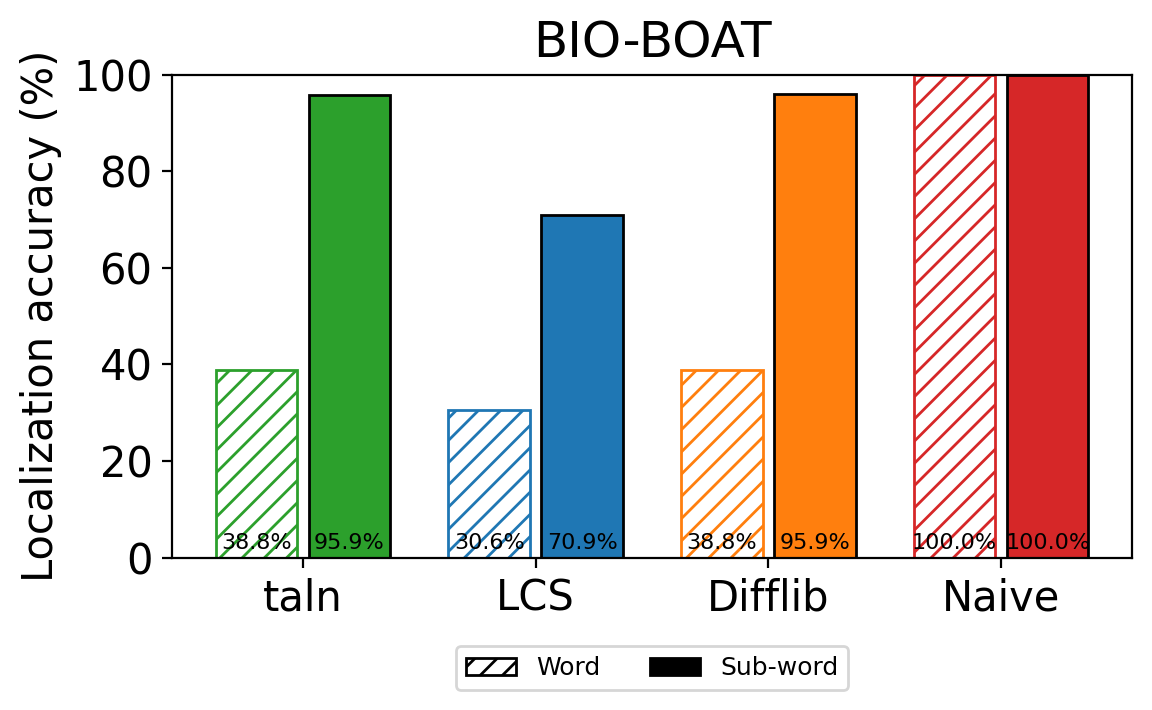

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

fig, ax = plt.subplots(figsize=(6, 4))

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}
x = np.arange(len(methods.keys()))

width = 0.35
gap = 0.025

# --- sub-word (tacc) ---------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y = tacc[f"{m}_loc"]
    y_mean = np.mean(y)
    center = idx + (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],   # solid color
        zorder=0,
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)

# --- word (wacc) -------------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y = wacc[f"{m}_loc"]
    y_mean = np.mean(y)
    center = idx - (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",           # stripes
        linewidth=1,
        zorder=0,
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)


# --- axes / labels -----------------------------------------------------------
ax.set(
    ylabel="Localization accuracy (%)",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0, 100),
    title="BIO-BOAT"
)

# legend
legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.show()


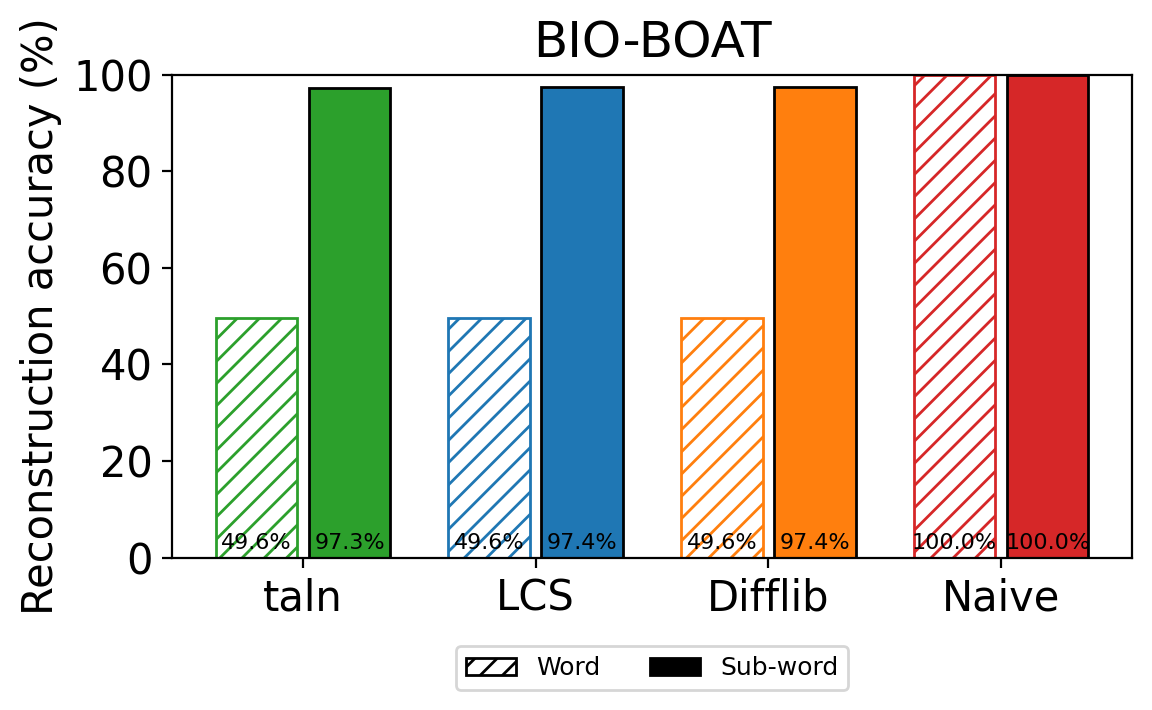

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

fig, ax = plt.subplots(figsize=(6, 4))

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}
x = np.arange(len(methods.keys()))

width = 0.35
gap = 0.025

# --- sub-word (tmatch) -------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y = tmatch[f"{m}_match"]
    y_mean = np.mean(y)
    center = idx + (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)

# --- word (wmatch) -----------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y = wmatch[f"{m}_match"]
    y_mean = np.mean(y)
    center = idx - (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
    )

    ax.text(center, 1, f"{y_mean:.1f}%",
            ha="center", va="bottom", fontsize=8)

ax.set(
    ylabel="Reconstruction accuracy (%)",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0, 100),
    title="BIO-BOAT"
)

legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.show()


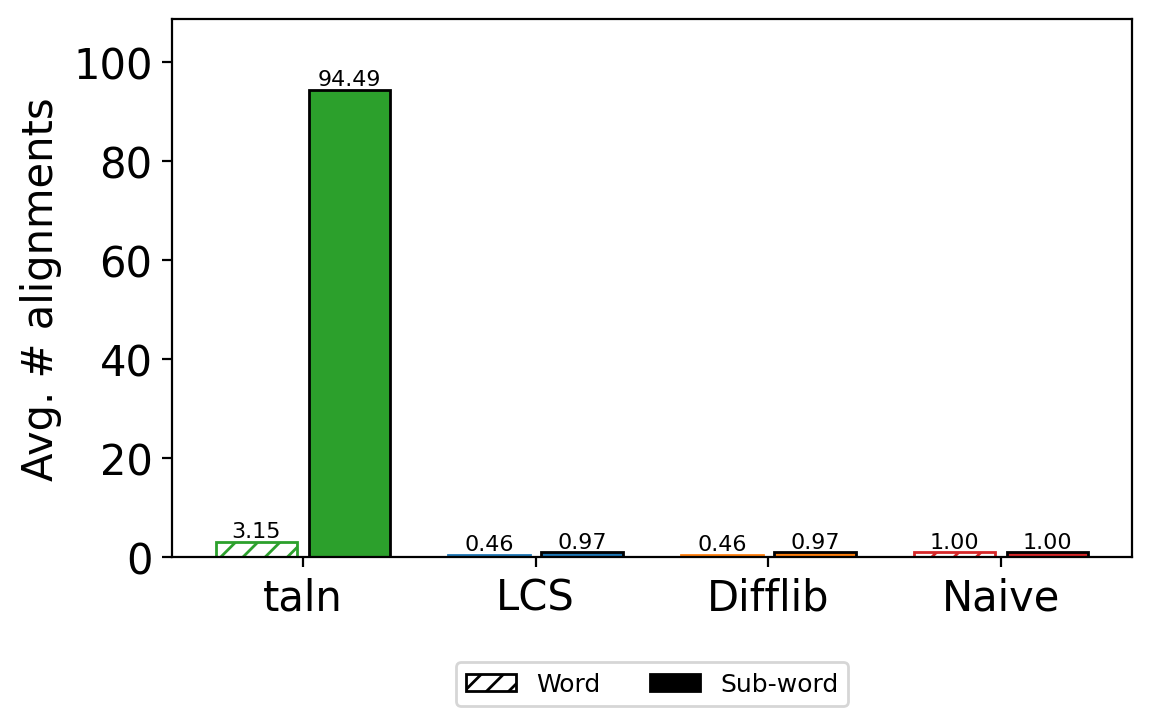

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Average number of FULL-MATCH alignments returned per (source,target) for each method.
# Sub-word = tdf (token) and Word = wdf (whitespace).

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}

fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(methods.keys()))
width = 0.35
gap = 0.025

# --- sub-word (tdf) ----------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_naln"].mean())
    center = idx + (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
    )

    ax.text(center, y_mean, f"{y_mean:.2f}", ha="center", va="bottom", fontsize=8)

# --- word (wdf) --------------------------------------------------------------
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_naln"].mean())
    center = idx - (width/2 + gap)

    ax.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
    )

    ax.text(center, y_mean, f"{y_mean:.2f}", ha="center", va="bottom", fontsize=8)

ax.set(
    ylabel="Avg. # alignments",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0, max(tdf[[f"{m}_naln" for m in methods.values()]].mean().max(), wdf[[f"{m}_naln" for m in methods.values()]].mean().max()) * 1.15),
)

legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.show()


In [12]:
# Variance of #FULL-MATCH alignments per (source,target) across the dataset
rows = []
for label, m in methods.items():
    rows.append({
        "method": label,
        "subword_mean": float(tdf[f"{m}_naln"].mean()),
        "subword_var": float(tdf[f"{m}_naln"].var()),
        "word_mean": float(wdf[f"{m}_naln"].mean()),
        "word_var": float(wdf[f"{m}_naln"].var()),
    })

var_tbl = pd.DataFrame(rows).set_index("method").round(3)
var_tbl


,subword_mean,subword_var,word_mean,word_var
method,,,,
taln,94.485,1.055089e+07,3.149,3619.960
LCS,0.969,3.000000e-02,0.457,0.248
Difflib,0.969,3.000000e-02,0.457,0.248
Naive,1.000,0.000000e+00,1.000,0.000


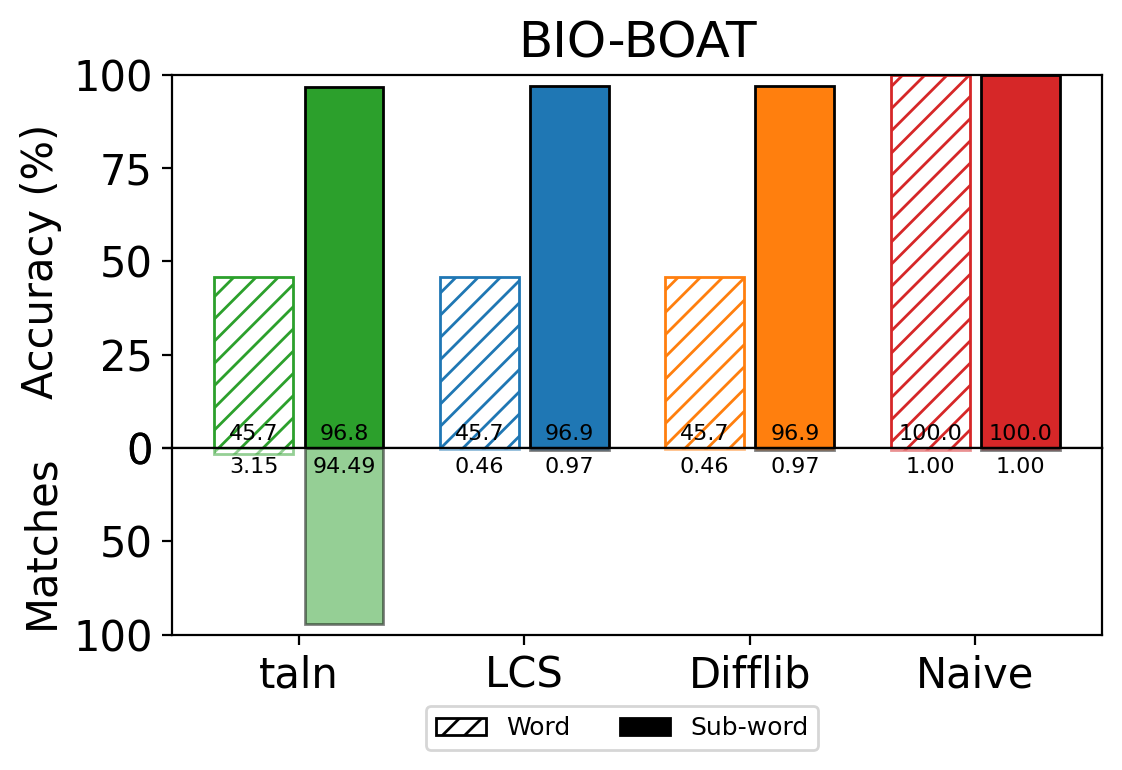

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

methods = {"taln": "custom", "LCS": "lcs", "Difflib": "difflib", "Naive": "naive"}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    figsize=(6, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# make the panels touch
fig.subplots_adjust(hspace=0)

x = np.arange(len(methods.keys()))
width = 0.35
gap = 0.025

# ===============================
# Top: reconstruction accuracy
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_match"].mean() * 100)
    center = idx + (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_match"].mean() * 100)
    center = idx - (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

ax_top.set(
    ylabel="Accuracy (%)",
    ylim=(0, 100),
    title="BIO-BOAT"
)

# hide top x tick labels (shared x-axis)
ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

# ===============================
# Bottom: avg # alignments (flipped)
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_naln"].mean())
    center = idx + (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.2f}", ha="center", va="top", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_naln"].mean())
    center = idx - (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.2f}", ha="center", va="top", fontsize=8)

ax_bot.set(
    ylabel="Matches",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0,100)
)

# flip y-axis so it reads like the barplot is glued upside-down
ax_bot.invert_yaxis()

# remove the touching spines so the join reads as a single panel
# ax_top.spines["bottom"].set_visible(False)

# ax_bot.spines["top"].set_visible(False)

legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

# legend below the bottom x tick labels
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=True,
    fontsize=9,
)

# NOTE: avoid tight_layout() here; it tends to re-introduce hspace.
fig.subplots_adjust(hspace=0, bottom=0.18)

plt.show()


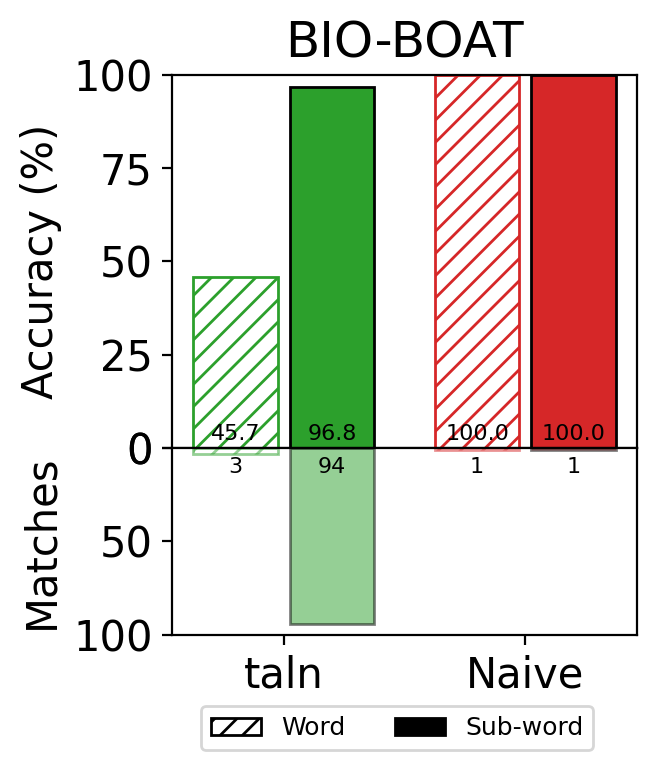

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "lcs":     "#1f77b4",  # blue
    "custom":  "#2ca02c",  # green
    "difflib": "#ff7f0e",  # orange
    "naive":   "#d62728",  # red
}

methods = {
    "taln": "custom", 
    # "LCS": "lcs", 
    # "Difflib": "difflib", 
    "Naive": "naive"}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    figsize=(3, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# make the panels touch
fig.subplots_adjust(hspace=0)

x = np.arange(len(methods.keys()))
width = 0.35
gap = 0.025

# ===============================
# Top: reconstruction accuracy
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_match"].mean() * 100)
    center = idx + (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_match"].mean() * 100)
    center = idx - (width/2 + gap)

    ax_top.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
    )

    ax_top.text(center, 1, f"{y_mean:.1f}", ha="center", va="bottom", fontsize=8)

ax_top.set(
    ylabel="Accuracy (%)",
    ylim=(0, 100),
    title="BIO-BOAT"
)

# hide top x tick labels (shared x-axis)
ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

# ===============================
# Bottom: avg # alignments (flipped)
# ===============================
for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(tdf[f"{m}_naln"].mean())
    center = idx + (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor="black",
        facecolor=COLORS[m],
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.0f}", ha="center", va="top", fontsize=8)

for idx, (label, m) in enumerate(methods.items()):
    y_mean = float(wdf[f"{m}_naln"].mean())
    center = idx - (width/2 + gap)

    ax_bot.bar(
        center, y_mean, width,
        edgecolor=COLORS[m],
        facecolor="white",
        hatch="///",
        linewidth=1,
        zorder=0,
        alpha=0.5
    )

    ax_bot.text(center, 5, f"{y_mean:.0f}", ha="center", va="top", fontsize=8)

ax_bot.set(
    ylabel="Matches",
    xticks=x,
    xticklabels=list(methods.keys()),
    ylim=(0,100)
)

# flip y-axis so it reads like the barplot is glued upside-down
ax_bot.invert_yaxis()

# remove the touching spines so the join reads as a single panel
# ax_top.spines["bottom"].set_visible(False)

# ax_bot.spines["top"].set_visible(False)

legend_elements = [
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Word"),
    Patch(facecolor="k", edgecolor="black", label="Sub-word"),
]

# legend below the bottom x tick labels
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=True,
    fontsize=9,
)

# NOTE: avoid tight_layout() here; it tends to re-introduce hspace.
fig.subplots_adjust(hspace=0, bottom=0.18)

plt.show()


In [15]:
tdf

,source,target,idx_start,custom_aln,custom_time_ms,custom_naln,custom_pairs,custom_idx_start,custom_idx_stop,custom_match,...,naive_time_ms,naive_naln,naive_pairs,naive_idx_start,naive_idx_stop,naive_match,custom_loc,lcs_loc,difflib_loc,naive_loc
0,""" All-in-one"" models of aging in general do no...",Some aging pathways involve interactions betw...,{343},"[[{'token': ' Some', 'enc_token': 4427, 'start...",85.055113,1,"{(343, 406)}",{343},{406},True,...,0.036240,1,"{(343, 406)}",{343},{406},True,True,True,True,True
1,""" All-in-one"" models of aging in general do no...",There is nothing in this generative model of ...,{655},"[[{'token': ' There', 'enc_token': 2684, 'star...",0.320911,1,"{(655, 771)}",{655},{771},True,...,0.010014,1,"{(655, 771)}",{655},{771},True,True,True,True,True
2,"""Brain age delta"" is the difference between ag...","for the most common approaches, which estimat...",{804},"[[{'token': ' for', 'enc_token': 369, 'start_i...",0.701189,4,"{(575, 919), (774, 919), (804, 919)}","{804, 774, 575}",{919},True,...,0.015259,1,"{(804, 919)}",{804},{919},True,True,True,True,True
3,"""Brain age delta"" is the difference between ag...",from cross-sectional (single timepoint) imagi...,{281},"[[{'token': ' from', 'enc_token': 505, 'start_...",0.535965,2,"{(57, 469), (281, 469)}","{57, 281}",{469},True,...,0.014067,1,"{(281, 469)}",{281},{469},True,True,True,True,True
4,"""Brain age delta"" is the difference between ag...",using longitudinal (two timepoint) data from ...,{1126},"[[{'token': ' using', 'enc_token': 1701, 'star...",0.441790,1,"{(1126, 1204)}",{1126},{1204},True,...,0.006914,1,"{(1126, 1204)}",{1126},{1204},True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5311,•H1: There are differences in light logger-der...,H2: There are differences in light logger-deri...,{196},"[[{'token': 'H', 'enc_token': 39, 'start_idx':...",0.195026,15,"{(141, 358), (141, 303), (1, 358), (1, 303), (...","{1, 196, 141}","{358, 303}",True,...,0.005960,1,"{(196, 303)}",{196},{303},True,True,False,True,True
5312,•H3: There are differences in LEBA items and f...,H3: There are differences in LEBA items and fa...,{1},"[[{'token': 'H', 'enc_token': 39, 'start_idx':...",0.154018,5,"{(1, 85), (1, 140)}",{1},"{140, 85}",True,...,0.006199,1,"{(1, 85)}",{1},{85},True,True,False,True,True
5313,•H3: There are differences in LEBA items and f...,H4: LEBA scores vary over time within particip...,{143},"[[{'token': 'H', 'enc_token': 39, 'start_idx':...",0.139952,6,"{(143, 259), (88, 193), (1, 259), (1, 193), (1...","{88, 1, 143}","{193, 259}",True,...,0.005245,1,"{(143, 193)}",{143},{193},True,True,False,True,True
5314,•H5: LEBA items correlate with preselected lig...,H5: LEBA items correlate with preselected ligh...,{1},"[[{'token': 'H', 'enc_token': 39, 'start_idx':...",0.187159,10,"{(1, 228), (1, 88)}",{1},"{88, 228}",True,...,0.005007,1,"{(1, 88)}",{1},{88},True,True,False,True,True


In [20]:
# --- BioBOAT dataset table (contiguous vs non-contiguous) ---------------------
# IMPORTANT: compute stats from the already-processed frames used in the figures.
# This keeps N, token counts, and alignment counts consistent with the plots.

import hashlib


def ws_len(s):
    return len(str(s).split())


def tok_len(s, ttype="token"):
    toks, _ = tokenize(str(s), ttype)
    return len(toks)


def pair_id_from_row(source: str, target: str) -> int:
    h = hashlib.sha256((source + "\n" + target).encode("utf-8")).hexdigest()
    return int(h[:8], 16)


def ablate_token_target(source: str, target: str) -> str:
    # Deterministic interior-token removal at the subword level.
    toks, _ = tokenize(target, "token")
    if len(toks) < 3:
        return target

    pid = pair_id_from_row(source, target)
    idx = 1 + (pid % (len(toks) - 2))
    toks.pop(idx)
    return reconstruct_target_by_token("", toks, "")


def summarize_pairs(df, n_align, target_col):
    n_align = pd.Series(n_align).reset_index(drop=True)

    src = df["source"].astype(str)
    tgt = df[target_col].astype(str)

    return {
        "n_pairs": int(df.shape[0]),
        "n_zero_align_tok": int((n_align == 0).sum()),
        # mean over ALL pairs (including zeros) to match the figures
        "mean_align_tok": float(n_align.mean()),
        "mean_source_chars": float(src.str.len().mean()),
        "mean_source_ws": float(src.apply(ws_len).mean()),
        "mean_source_tok": float(src.apply(tok_len).mean()),
        "mean_target_chars": float(tgt.str.len().mean()),
        "mean_target_ws": float(tgt.apply(ws_len).mean()),
        "mean_target_tok": float(tgt.apply(tok_len).mean()),
    }


# contiguous: reuse the exact tdf used in the benchmark figures
bio_contig = tdf.reset_index(drop=True).copy()

# Use full-match alignment counts (custom_naln) to match the plotting code
contig_n = bio_contig["custom_naln"]

bio_tbl = pd.DataFrame(
    {
        "contiguous_bio": summarize_pairs(bio_contig, contig_n, target_col="target"),
    }
).T

# Note: the non-contiguous (BIO) row should be computed from the actual ablated dataset
# used in analysis/notebooks/ablate_bioboat.ipynb, so that its counts match that notebook's figures.

cols = [
    "n_pairs",
    "n_zero_align_tok",
    "mean_align_tok",
    "mean_source_chars",
    "mean_source_ws",
    "mean_source_tok",
    "mean_target_chars",
    "mean_target_ws",
    "mean_target_tok",
]

bio_tbl = bio_tbl[cols]

display(
    bio_tbl.round(
        {
            "n_pairs": 0,
            "n_zero_align_tok": 0,
            "mean_align_tok": 3,
            "mean_source_chars": 1,
            "mean_source_ws": 1,
            "mean_source_tok": 1,
            "mean_target_chars": 1,
            "mean_target_ws": 1,
            "mean_target_tok": 1,
        }
    )
)



,n_pairs,n_zero_align_tok,mean_align_tok,mean_source_chars,mean_source_ws,mean_source_tok,mean_target_chars,mean_target_ws,mean_target_tok
contiguous_bio,5316.0,171.0,94.485,606.8,91.1,131.9,97.0,14.3,19.8


BioBOAT tdf (token) alignment counts:
count      5316.000
mean         94.547
std        3248.212
min           0.000
50%           1.000
90%           9.000
95%          24.000
99%         349.600
max      223922.000
Name: custom_aln, dtype: float64

===
n_alignments: 223922
n_full_recon_pairs: 16
sample (start,end) pairs: [(27, 937), (27, 1056), (27, 590), (27, 1699), (27, 1329), (27, 188), (27, 255), (27, 695)]
target tok len: 27
target: ' monocytes, when co-cultured with endothelial cells secrete the anti-angiogenic isoforms VEGF-A165b'
source.find(target): 27
most common source tokens: [(' V', 24), ('EG', 24), ('F', 24), ('-A', 23), (' the', 22), ('165', 20), (' to', 18), ('b', 16), (' that', 11), ('.', 11), (' ', 11), (' in', 10)]

===
n_alignments: 48165
n_full_recon_pairs: 30
sample (start,end) pairs: [(269, 746), (372, 1601), (475, 650), (269, 1347), (269, 572), (475, 811), (269, 953), (372, 914)]
target tok len: 28
target: ' SRPK1 inhibition switches splicing from the VEGF-A1